<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/CNN_v12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN LOB -- Ablation Study v4

**Changes from v3:**
- Early stopping: val_acc → directional F1 (Down+Up only)
- shuffle=True in train loader
- label_smoothing removed
- SEQ_LEN: 30 → 10
- DROPOUT: 0.3 → 0.1
- PATIENCE: 6 → 12, EPOCHS: 30 → 50
- GAP → Last Timestep
- N_BLOCKS: 3 → 2


In [1]:
import math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/629/'
df_full      = pd.read_csv(DATA_PATH + 'lob_full.csv')
df_no_pca    = pd.read_csv(DATA_PATH + 'lob_no_pca.csv')
df_no_market = pd.read_csv(DATA_PATH + 'lob_no_market.csv')

META_COLS = ['label', 'future_return', 'split']
full_feat_cols      = [c for c in df_full.columns      if c not in META_COLS]
no_pca_feat_cols    = [c for c in df_no_pca.columns    if c not in META_COLS]
no_market_feat_cols = [c for c in df_no_market.columns if c not in META_COLS]

split_idx = int((df_full['split'] == 'train').sum())

print('lob_full      shape:', df_full.shape,      '| features:', len(full_feat_cols))
print('lob_no_pca    shape:', df_no_pca.shape,    '| features:', len(no_pca_feat_cols))
print('lob_no_market shape:', df_no_market.shape, '| features:', len(no_market_feat_cols))
print('Train rows:', split_idx, '| Test rows:', len(df_full) - split_idx)
gc.collect()


Mounted at /content/drive
lob_full      shape: (99841, 41) | features: 38
lob_no_pca    shape: (99841, 91) | features: 88
lob_no_market shape: (99841, 26) | features: 23
Train rows: 79872 | Test rows: 19969


0

In [2]:
# ============================================================
# CHOOSE YOUR ABLATION DATASET
#   'full'      -> PCA(top-N) + market + classic
#   'no_pca'    -> raw LOB   + market + classic
#   'no_market' -> PCA(top-N) + classic only
# ============================================================
FEATURE_SET = 'full'

SEED        = 42
SEQ_LEN     = 10       # ← was 30; label horizon is 10s so 30 adds noise
N_FILTERS   = 64
KERNEL_SIZE = 3
N_BLOCKS    = 2        # ← was 3; reduce capacity to avoid Flat memorisation
DROPOUT     = 0.1      # ← was 0.3; model is underfitting, not overfitting
BATCH_SIZE  = 256
EPOCHS      = 50       # ← was 30; dir F1 needs more epochs to climb
LR          = 1e-4     # ← was 3e-4; smaller LR for more stable directional learning
PATIENCE    = 12       # ← was 6; more patience for dir F1 early stopping
WD          = 1e-3

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


def select_features(feature_set):
    if feature_set == 'full':
        df, feat_cols = df_full, full_feat_cols
    elif feature_set == 'no_pca':
        df, feat_cols = df_no_pca, no_pca_feat_cols
    elif feature_set == 'no_market':
        df, feat_cols = df_no_market, no_market_feat_cols
    else:
        raise ValueError('Unknown feature_set: ' + feature_set)
    print('Feature set:', feature_set.upper(), '| features:', len(feat_cols))
    X = df[feat_cols].values.astype(np.float32)
    y = (df['label'].values + 1).astype(np.int64)   # {-1,0,1} -> {0,1,2}
    print('X shape:', X.shape, '| y shape:', y.shape)
    print('Label dist (down/flat/up):',
          np.round(np.bincount(y, minlength=3) / len(y), 3))
    return X, y


class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]


def build_loaders(X, y):
    local_split  = min(split_idx, len(X) - 1)
    X_tr, X_te   = X[:local_split], X[local_split:]
    y_tr, y_te   = y[:local_split], y[local_split:]

    counts  = np.bincount(y_tr, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts),
                            dtype=torch.float32).to(DEVICE)

    # shuffle=True: breaks temporal autocorrelation in batches
    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print('Train samples:', len(train_loader.dataset),
          '| Test samples:', len(test_loader.dataset))
    print('Class weights (down/flat/up):', class_w.cpu().numpy().round(3))
    return train_loader, test_loader, class_w


Device: cuda


## CNN Model Architecture

Changes: N_BLOCKS 3→2, GAP→Last Timestep

In [3]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dropout=0.1):
        super().__init__()
        pad = kernel_size // 2
        self.conv1   = nn.Conv1d(in_channels, out_channels, kernel_size, padding=pad)
        self.bn1     = nn.BatchNorm1d(out_channels)
        self.conv2   = nn.Conv1d(out_channels, out_channels, kernel_size, padding=pad)
        self.bn2     = nn.BatchNorm1d(out_channels)
        self.skip    = (nn.Conv1d(in_channels, out_channels, kernel_size=1)
                        if in_channels != out_channels else nn.Identity())
        self.act     = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = self.skip(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.dropout(self.act(out + residual))


class TemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size=3, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1   = nn.Conv1d(channels, channels, kernel_size,
                                  padding=pad, dilation=dilation)
        self.bn1     = nn.BatchNorm1d(channels)
        self.conv2   = nn.Conv1d(channels, channels, kernel_size,
                                  padding=pad, dilation=dilation)
        self.bn2     = nn.BatchNorm1d(channels)
        self.act     = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.chomp   = lambda x, p: x[:, :, :-p] if p > 0 else x

    def forward(self, x):
        pad = self.conv1.padding[0]
        out = self.act(self.bn1(self.chomp(self.conv1(x), pad)))
        out = self.bn2(self.chomp(self.conv2(out), pad))
        return self.dropout(self.act(out + x))


class LOBCNN(nn.Module):
    """
    v4 changes vs v3:
      - N_BLOCKS 3 -> 2  (less capacity, harder to memorise Flat prior)
      - Global Average Pool -> Last Timestep  (current LOB state > history average)
    """
    def __init__(self, n_features):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Conv1d(n_features, N_FILTERS, kernel_size=1),
            nn.BatchNorm1d(N_FILTERS),
            nn.GELU()
        )

        res_blocks = []
        in_ch = N_FILTERS
        for i in range(N_BLOCKS):
            out_ch = min(N_FILTERS * (2 ** i), N_FILTERS * 4)
            res_blocks.append(ResidualBlock1D(in_ch, out_ch, KERNEL_SIZE, DROPOUT))
            in_ch = out_ch
        self.res_blocks = nn.Sequential(*res_blocks)

        self.tcn_blocks = nn.ModuleList([
            TemporalBlock(in_ch, kernel_size=KERNEL_SIZE,
                          dilation=2**i, dropout=DROPOUT)
            for i in range(N_BLOCKS)
        ])

        # ← Last Timestep instead of Global Average Pool
        # Rationale: current LOB state is far more predictive than the
        # time-averaged state; GAP dilutes the signal with stale history.
        # self.gap = nn.AdaptiveAvgPool1d(1)  # removed

        self.head = nn.Sequential(
            nn.Linear(in_ch, in_ch // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(in_ch // 2, 3)
        )

        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.permute(0, 2, 1)          # (B,T,F) -> (B,F,T)
        x = self.input_proj(x)           # -> (B, N_FILTERS, T)
        x = self.res_blocks(x)           # -> (B, out_ch, T)
        for block in self.tcn_blocks:
            x = block(x)
        x = x[:, :, -1]                  # Last Timestep -> (B, C)
        return self.head(x)              # -> (B, 3)


def build_model(n_features):
    model    = LOBCNN(n_features).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('Model params: %s  |  Input features: %d' % (f'{n_params:,}', n_features))
    return model


## Training & Evaluation

Changes: directional F1 early stopping, no label_smoothing

In [4]:
def train(model, train_loader, test_loader, class_w):
    # label_smoothing removed: softens targets -> hurts minority class gradient
    criterion = nn.CrossEntropyLoss(weight=class_w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_dir_f1': []}
    best_dir_f1, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        # train
        model.train(); running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(yb)
        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        # validate
        model.eval()
        vloss, correct, total = 0.0, 0, 0
        ep_preds, ep_true = [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb  = Xb.to(DEVICE), yb.to(DEVICE)
                logits   = model(Xb)
                vloss   += criterion(logits, yb).item() * len(yb)
                preds    = logits.argmax(1)
                correct += (preds == yb).sum().item()
                total   += len(yb)
                ep_preds.append(preds.cpu().numpy())
                ep_true.append(yb.cpu().numpy())

        val_loss = vloss / total
        val_acc  = correct / total

        # directional F1: only Down(0) and Up(2), ignore Flat(1)
        all_preds = np.concatenate(ep_preds)
        all_true  = np.concatenate(ep_true)
        dir_f1 = f1_score(all_true, all_preds,
                          labels=[0, 2], average='macro', zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_dir_f1'].append(dir_f1)

        print('Ep %3d/%d | Train %.4f | Val %.4f | Acc %.4f | DirF1 %.4f'
              % (epoch, EPOCHS, train_loss, val_loss, val_acc, dir_f1))

        # early stopping on directional F1
        if dir_f1 > best_dir_f1:
            best_dir_f1, patience_cnt = dir_f1, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print('Early stop at epoch %d. Best DirF1: %.4f'
                      % (epoch, best_dir_f1))
                break

    model.load_state_dict(best_state)
    return history, best_dir_f1


def evaluate(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            all_preds.append(model(Xb.to(DEVICE)).argmax(1).cpu().numpy())
            all_labels.append(yb.numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    print(classification_report(y_true, y_pred,
                                target_names=['Down', 'Flat', 'Up'],
                                zero_division=0))
    return y_pred, y_true


def plot_results(history, y_pred, y_true, title=""):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle("CNN LOB v4 -- " + title, fontsize=14)
    ep = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(ep, history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
    axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, history["val_acc"], color="seagreen")
    axes[1].axhline(max(history["val_acc"]), color="tomato", linestyle="--",
                    label="Best=%.4f" % max(history["val_acc"]))
    axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(ep, history["val_dir_f1"], color="darkorange")
    axes[2].axhline(max(history["val_dir_f1"]), color="tomato", linestyle="--",
                    label="Best=%.4f" % max(history["val_dir_f1"]))
    axes[2].set_title("Directional F1 (Down+Up, early-stop criterion)")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[3],
                xticklabels=["Down", "Flat", "Up"],
                yticklabels=["Down", "Flat", "Up"])
    axes[3].set_title("Confusion Matrix")
    axes[3].set_xlabel("Predicted"); axes[3].set_ylabel("True")
    plt.tight_layout(); plt.show()


## Run Pipeline

## Backtest Engine

In [5]:
# ============================================================
# BACKTEST ENGINE  (ported from LSTM framework)
# ============================================================
EMBARGO_GAP = 10
FEE         = 0.00015   # 万分之五单边手续费


def simple_backtest(y_pred_labels, future_returns, fee=FEE, exp_name="Strategy"):
    """
    向量化回测引擎（复利版）
    y_pred_labels : np.ndarray  (0=Down, 1=Flat, 2=Up)
    future_returns: np.ndarray  对应时间步的真实收益率
    fee           : float       单边手续费
    """
    signals = y_pred_labels - 1                            # {0,1,2} -> {-1,0,1}
    trades  = np.abs(np.diff(signals, prepend=0))          # 换手量
    transaction_costs = trades * fee

    net_returns = (signals * future_returns) - transaction_costs
    cum_returns = np.cumprod(1 + net_returns)              # 复利资金曲线
    market_cum  = np.cumprod(1 + future_returns)           # 大盘基准

    total_return = cum_returns[-1] - 1
    annual_factor = 365 * 24 * 3600
    sharpe = np.mean(net_returns) / (np.std(net_returns) + 1e-8) * np.sqrt(annual_factor)

    running_max  = np.maximum.accumulate(cum_returns)
    max_drawdown = np.min((cum_returns - running_max) / running_max)

    active_periods = (signals != 0).sum()
    win_rate = (net_returns > 0).sum() / (active_periods + 1e-8)

    print("\n" + "-" * 50)
    print(f"📊 BACKTEST: {exp_name}  (Fee: {fee*10000:.1f} bps)")
    print("-" * 50)
    print(f"Total Net Return : {total_return:.2%}")
    print(f"Annualized Sharpe: {sharpe:.2f}")
    print(f"Max Drawdown     : {max_drawdown:.2%}")
    print(f"Win Rate         : {win_rate:.2%}")
    print(f"Total Turnover   : {int(trades.sum()):,}  (position changes)")

    plt.figure(figsize=(10, 4))
    plt.plot(market_cum,  label="Buy & Hold Benchmark", color="gray",  alpha=0.5, linewidth=1.5)
    plt.plot(cum_returns, label=f"CNN Net Return",      color="steelblue", linewidth=2)
    plt.title(f"Equity Curve — {exp_name}  (Fee: {fee*10000:.1f} bps)", fontweight="bold")
    plt.ylabel("Cumulative Wealth"); plt.xlabel("Time Steps")
    plt.legend(loc="upper left"); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return total_return, sharpe, max_drawdown


def get_test_returns(df, split_idx):
    """
    从原始 DataFrame 中对齐测试集的 future_return。
    与 build_loaders 中的 embargo 和 LOBDataset 的滑窗偏移保持一致。
    """
    returns_all = df["future_return"].values
    start_idx   = split_idx + EMBARGO_GAP + SEQ_LEN - 1
    return returns_all[start_idx:]


## Run Experiments (CNN + Backtest)

  CNN LOB v4 -- feature_set = full
Feature set: FULL | features: 38
X shape: (99841, 38) | y shape: (99841,)
Label dist (down/flat/up): [0.216 0.569 0.215]
Train samples: 79863 | Test samples: 19960
Class weights (down/flat/up): [1.48  0.603 1.501]
Model params: 316,995  |  Input features: 38

--- Training ---
Ep   1/50 | Train 1.2367 | Val 1.1025 | Acc 0.3664 | DirF1 0.2628
Ep   2/50 | Train 1.1089 | Val 1.0908 | Acc 0.3569 | DirF1 0.2897
Ep   3/50 | Train 1.0965 | Val 1.0937 | Acc 0.3190 | DirF1 0.2926
Ep   4/50 | Train 1.0926 | Val 1.0920 | Acc 0.3290 | DirF1 0.2927
Ep   5/50 | Train 1.0896 | Val 1.0870 | Acc 0.3608 | DirF1 0.2935
Ep   6/50 | Train 1.0881 | Val 1.0887 | Acc 0.3567 | DirF1 0.2969
Ep   7/50 | Train 1.0867 | Val 1.0886 | Acc 0.3502 | DirF1 0.2965
Ep   8/50 | Train 1.0857 | Val 1.0889 | Acc 0.3422 | DirF1 0.2911
Ep   9/50 | Train 1.0848 | Val 1.0926 | Acc 0.3284 | DirF1 0.2973
Ep  10/50 | Train 1.0844 | Val 1.0889 | Acc 0.3395 | DirF1 0.2974
Ep  11/50 | Train 1.0830 | V

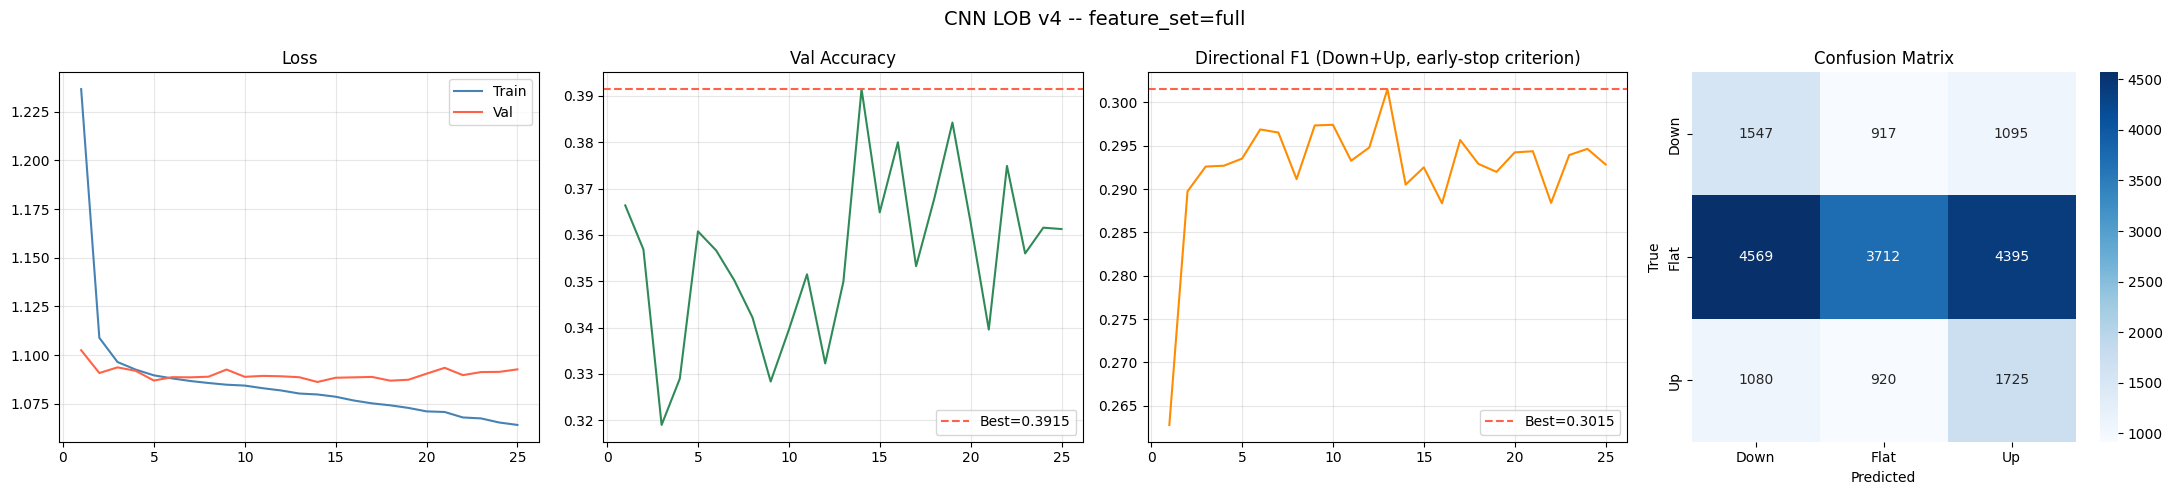


--- Backtesting ---

--------------------------------------------------
📊 BACKTEST: CNN (full)  (Fee: 1.5 bps)
--------------------------------------------------
Total Net Return : -50.82%
Annualized Sharpe: -781.43
Max Drawdown     : -50.85%
Win Rate         : 34.72%
Total Turnover   : 5,950  (position changes)


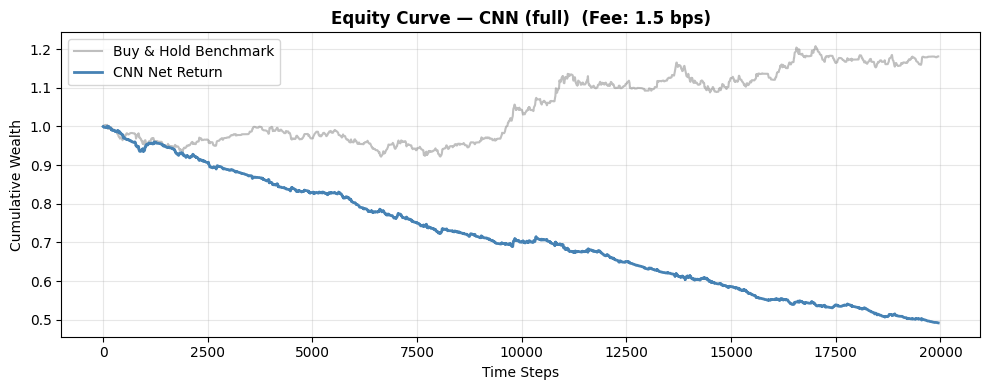

In [6]:
def run_cnn(feature_set):
    print("=" * 60)
    print("  CNN LOB v4 -- feature_set = " + feature_set)
    print("=" * 60)

    # ---- 选择数据集 ----
    if feature_set == "full":
        df = df_full
    elif feature_set == "no_pca":
        df = df_no_pca
    elif feature_set == "no_market":
        df = df_no_market
    else:
        raise ValueError("Unknown feature_set: " + feature_set)

    X, y                       = select_features(feature_set)
    train_ld, test_ld, class_w = build_loaders(X, y)
    model                      = build_model(n_features=X.shape[1])

    print("\n--- Training ---")
    history, best_dir_f1 = train(model, train_ld, test_ld, class_w)

    print("\n--- Evaluation ---")
    y_pred, y_true = evaluate(model, test_ld)
    plot_results(history, y_pred, y_true, title="feature_set=" + feature_set)

    # ---- 回测 ----
    print("\n--- Backtesting ---")
    test_returns = get_test_returns(df, split_idx)
    # 防止长度不匹配（取较短一方）
    min_len = min(len(y_pred), len(test_returns))
    assert min_len > 0, "回测对齐后长度为0，请检查 split_idx 与 EMBARGO_GAP。"
    ret, sharpe, max_dd = simple_backtest(
        y_pred[:min_len], test_returns[:min_len],
        fee=FEE, exp_name=f"CNN ({feature_set})"
    )

    return model, history, y_pred, y_true, ret, sharpe, max_dd


model_full, history_full, y_pred_full, y_true_full, ret_full, sharpe_full, dd_full = run_cnn("full")


### Experiment 2: No PCA

  CNN LOB v4 -- feature_set = no_pca
Feature set: NO_PCA | features: 88
X shape: (99841, 88) | y shape: (99841,)
Label dist (down/flat/up): [0.216 0.569 0.215]
Train samples: 79863 | Test samples: 19960
Class weights (down/flat/up): [1.48  0.603 1.501]
Model params: 320,195  |  Input features: 88

--- Training ---
Ep   1/50 | Train 1.2490 | Val 1.0897 | Acc 0.4115 | DirF1 0.2790
Ep   2/50 | Train 1.1075 | Val 1.0878 | Acc 0.3759 | DirF1 0.2910
Ep   3/50 | Train 1.0965 | Val 1.0881 | Acc 0.3845 | DirF1 0.2773
Ep   4/50 | Train 1.0936 | Val 1.0872 | Acc 0.3781 | DirF1 0.2882
Ep   5/50 | Train 1.0903 | Val 1.0887 | Acc 0.3468 | DirF1 0.3028
Ep   6/50 | Train 1.0900 | Val 1.0853 | Acc 0.3909 | DirF1 0.2936
Ep   7/50 | Train 1.0876 | Val 1.0857 | Acc 0.3703 | DirF1 0.2940
Ep   8/50 | Train 1.0865 | Val 1.0851 | Acc 0.3843 | DirF1 0.2907
Ep   9/50 | Train 1.0859 | Val 1.0860 | Acc 0.3705 | DirF1 0.3017
Ep  10/50 | Train 1.0853 | Val 1.0879 | Acc 0.3512 | DirF1 0.2998
Ep  11/50 | Train 1.0847

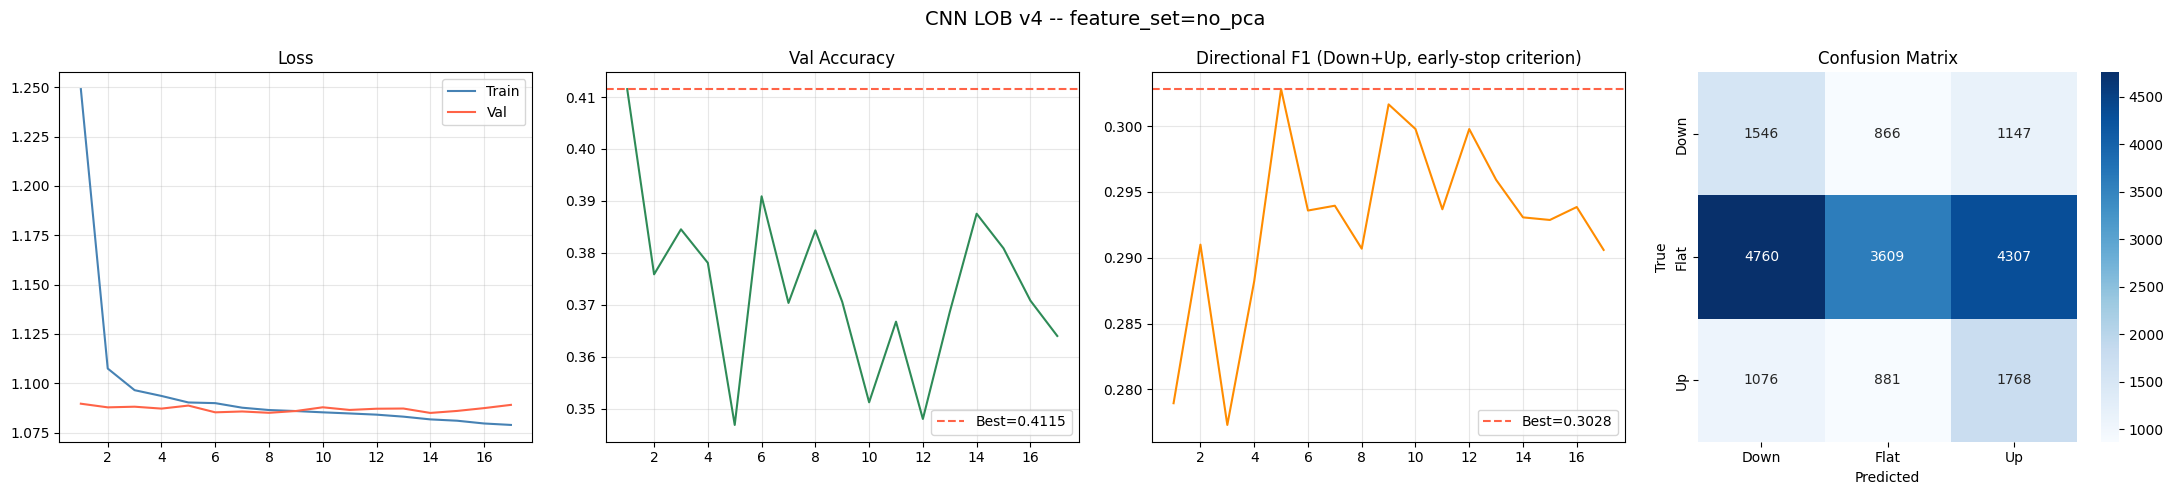


--- Backtesting ---

--------------------------------------------------
📊 BACKTEST: CNN (no_pca)  (Fee: 1.5 bps)
--------------------------------------------------
Total Net Return : -53.41%
Annualized Sharpe: -838.83
Max Drawdown     : -53.40%
Win Rate         : 34.90%
Total Turnover   : 6,344  (position changes)


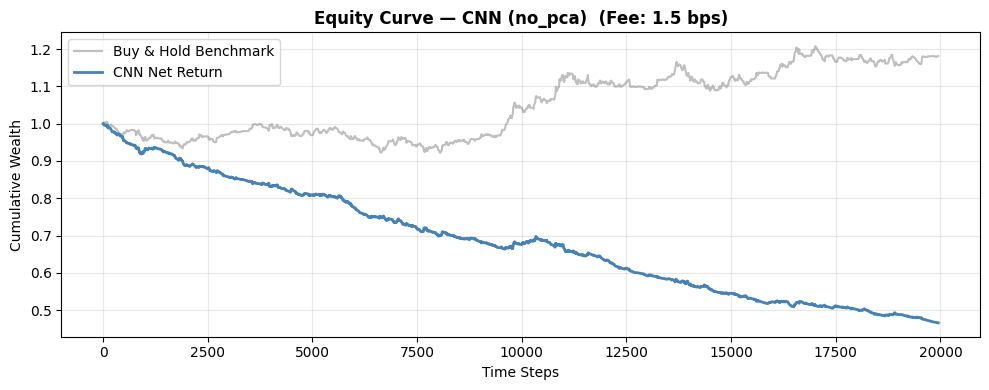

In [7]:
model_no_pca, history_no_pca, y_pred_no_pca, y_true_no_pca, ret_no_pca, sharpe_no_pca, dd_no_pca = run_cnn("no_pca")


### Experiment 3: No Market

  CNN LOB v4 -- feature_set = no_market
Feature set: NO_MARKET | features: 23
X shape: (99841, 23) | y shape: (99841,)
Label dist (down/flat/up): [0.216 0.569 0.215]
Train samples: 79863 | Test samples: 19960
Class weights (down/flat/up): [1.48  0.603 1.501]
Model params: 316,035  |  Input features: 23

--- Training ---
Ep   1/50 | Train 1.2648 | Val 1.0985 | Acc 0.4122 | DirF1 0.2584
Ep   2/50 | Train 1.1122 | Val 1.0862 | Acc 0.4091 | DirF1 0.2817
Ep   3/50 | Train 1.0962 | Val 1.0880 | Acc 0.3754 | DirF1 0.2787
Ep   4/50 | Train 1.0922 | Val 1.0850 | Acc 0.3949 | DirF1 0.2917
Ep   5/50 | Train 1.0894 | Val 1.0863 | Acc 0.3651 | DirF1 0.2920
Ep   6/50 | Train 1.0885 | Val 1.0843 | Acc 0.3933 | DirF1 0.2930
Ep   7/50 | Train 1.0856 | Val 1.0888 | Acc 0.3522 | DirF1 0.2954
Ep   8/50 | Train 1.0853 | Val 1.0852 | Acc 0.3818 | DirF1 0.2809
Ep   9/50 | Train 1.0851 | Val 1.0893 | Acc 0.3419 | DirF1 0.2864
Ep  10/50 | Train 1.0827 | Val 1.0918 | Acc 0.3271 | DirF1 0.2841
Ep  11/50 | Train 

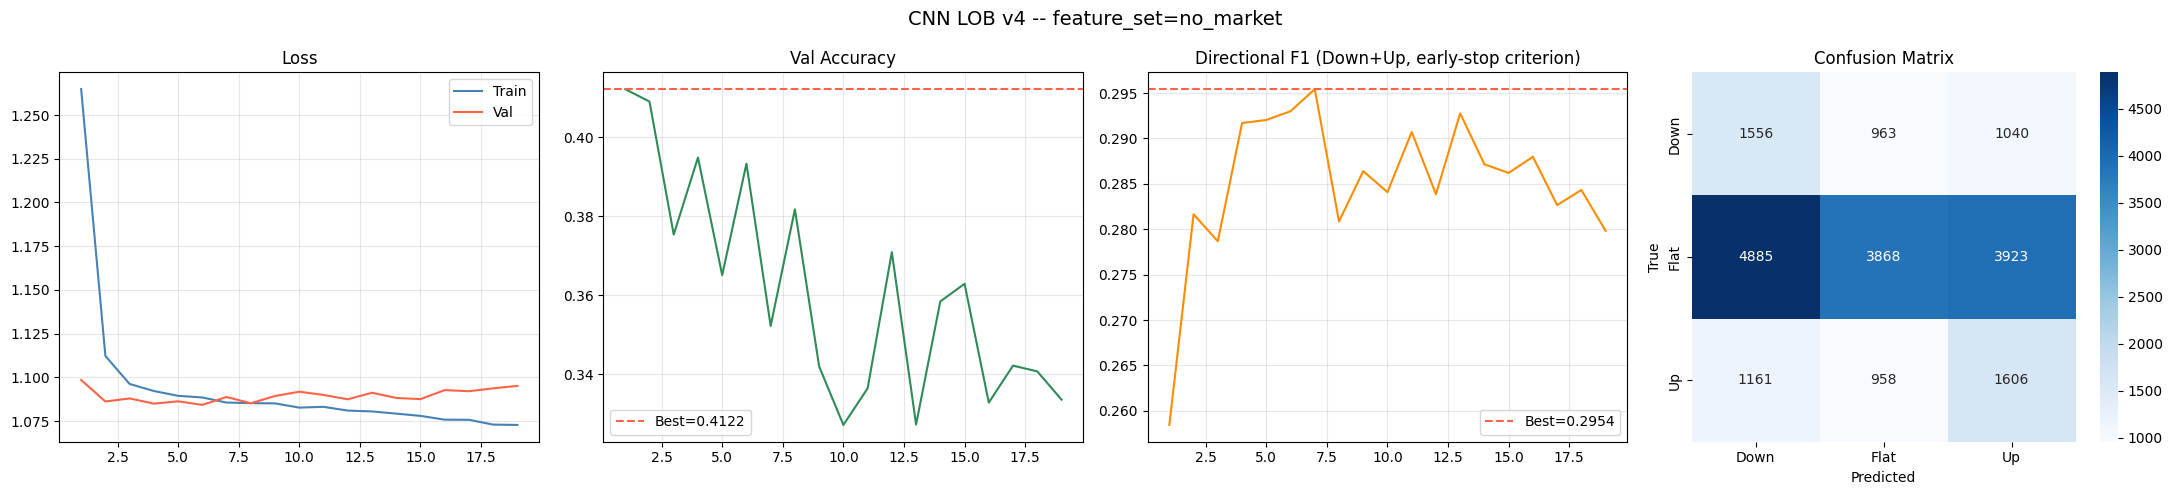


--- Backtesting ---

--------------------------------------------------
📊 BACKTEST: CNN (no_market)  (Fee: 1.5 bps)
--------------------------------------------------
Total Net Return : -55.28%
Annualized Sharpe: -883.61
Max Drawdown     : -55.27%
Win Rate         : 33.84%
Total Turnover   : 6,460  (position changes)


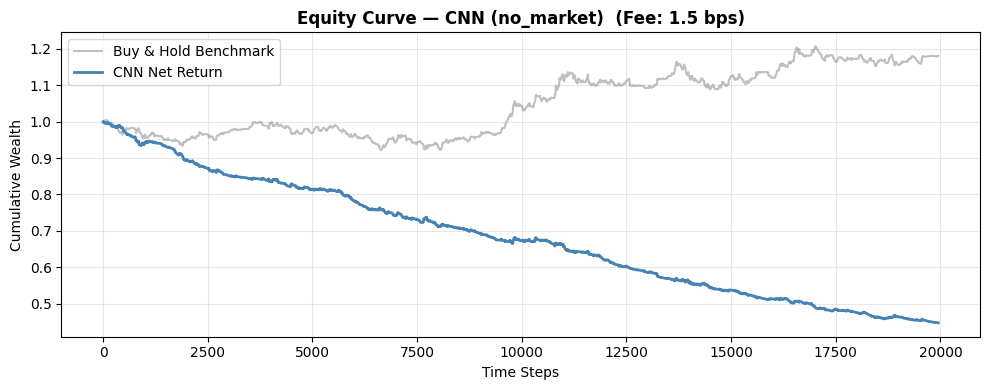

In [8]:
model_no_market, history_no_market, y_pred_no_market, y_true_no_market, ret_no_market, sharpe_no_market, dd_no_market = run_cnn("no_market")


## Ablation Summary (Classification + Backtest)

In [9]:
from sklearn.metrics import f1_score

def summarise(name, y_pred, y_true, net_ret, sharpe, max_dd):
    acc    = (y_pred == y_true).mean()
    macro  = f1_score(y_true, y_pred, average="macro",  zero_division=0)
    dir_f1 = f1_score(y_true, y_pred, labels=[0, 2], average="macro", zero_division=0)
    down   = f1_score(y_true, y_pred, labels=[0], average="macro", zero_division=0)
    up     = f1_score(y_true, y_pred, labels=[2], average="macro", zero_division=0)
    print(
        f"{name:<12} | Acc: {acc:.3f} | MacroF1: {macro:.3f} | DirF1: {dir_f1:.3f}"
        f" | Down F1: {down:.3f} | Up F1: {up:.3f}"
        f" | NetRet: {net_ret:.2%} | Sharpe: {sharpe:.2f} | MaxDD: {max_dd:.2%}"
    )

print("=" * 110)
print("ABLATION SUMMARY  (with Backtest Metrics)")
print("=" * 110)
summarise("Full",      y_pred_full,      y_true_full,      ret_full,      sharpe_full,      dd_full)
summarise("No PCA",    y_pred_no_pca,    y_true_no_pca,    ret_no_pca,    sharpe_no_pca,    dd_no_pca)
summarise("No Market", y_pred_no_market, y_true_no_market, ret_no_market, sharpe_no_market, dd_no_market)


ABLATION SUMMARY  (with Backtest Metrics)
Full         | Acc: 0.350 | MacroF1: 0.337 | DirF1: 0.302 | Down F1: 0.288 | Up F1: 0.315 | NetRet: -50.82% | Sharpe: -781.43 | MaxDD: -50.85%
No PCA       | Acc: 0.347 | MacroF1: 0.335 | DirF1: 0.303 | Down F1: 0.283 | Up F1: 0.323 | NetRet: -53.41% | Sharpe: -838.83 | MaxDD: -53.40%
No Market    | Acc: 0.352 | MacroF1: 0.337 | DirF1: 0.295 | Down F1: 0.279 | Up F1: 0.312 | NetRet: -55.28% | Sharpe: -883.61 | MaxDD: -55.27%
